In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# SciPy 2016 Scikit-learn Tutorial

# Supervised Learning Part 2 -- Regression Analysis

In regression we are trying to predict a continuous output variable -- in contrast to the nominal variables we were predicting in the previous classification examples. 

Let's start with a simple toy example with one feature dimension (explanatory variable) and one target variable. We will create a dataset out of a sinus curve with some noise:

In [3]:
x = np.linspace(-3, 3, 100)
print(x)

[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576 -2.6969697
 -2.63636364 -2.57575758 -2.51515152 -2.45454545 -2.39393939 -2.33333333
 -2.27272727 -2.21212121 -2.15151515 -2.09090909 -2.03030303 -1.96969697
 -1.90909091 -1.84848485 -1.78787879 -1.72727273 -1.66666667 -1.60606061
 -1.54545455 -1.48484848 -1.42424242 -1.36363636 -1.3030303  -1.24242424
 -1.18181818 -1.12121212 -1.06060606 -1.         -0.93939394 -0.87878788
 -0.81818182 -0.75757576 -0.6969697  -0.63636364 -0.57575758 -0.51515152
 -0.45454545 -0.39393939 -0.33333333 -0.27272727 -0.21212121 -0.15151515
 -0.09090909 -0.03030303  0.03030303  0.09090909  0.15151515  0.21212121
  0.27272727  0.33333333  0.39393939  0.45454545  0.51515152  0.57575758
  0.63636364  0.6969697   0.75757576  0.81818182  0.87878788  0.93939394
  1.          1.06060606  1.12121212  1.18181818  1.24242424  1.3030303
  1.36363636  1.42424242  1.48484848  1.54545455  1.60606061  1.66666667
  1.72727273  1.78787879  1.84848485  1.90909091  1.9

In [4]:
rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.uniform(size=len(x))

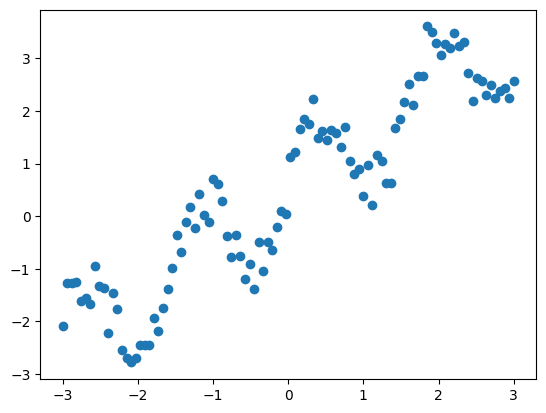

In [5]:
plt.plot(x, y, 'o');

Use "Pseudocode for the general square trick" in lecture to implement the linear regression algorithm with the generated data. 

Linear Regression
=================

The first model that we will introduce is the so-called simple linear regression. Here, we want to fit a line to the data, which 

One of the simplest models again is a linear one, that simply tries to predict the data as lying on a line. One way to find such a line is `LinearRegression` (also known as [*Ordinary Least Squares (OLS)*](https://en.wikipedia.org/wiki/Ordinary_least_squares) regression).
The interface for LinearRegression is exactly the same as for the classifiers before, only that ``y`` now contains float values, instead of classes.

As we remember, the scikit-learn API requires us to provide the target variable (`y`) as a 1-dimensional array; scikit-learn's API expects the samples (`X`) in form a 2-dimensional array -- even though it may only consist of 1 feature. Thus, let us convert the 1-dimensional `x` NumPy array into an `X` array with 2 axes:


In [7]:
# Scikit-learn yêu cầu:
# X (features): Phải là array 2D với shape (n_samples, n_features)
# y (target): Có thể là array 1D với shape (n_samples,)
print('Before: ', x.shape)
X = x[:, np.newaxis]
print('After: ', X.shape)

Before:  (100,)
After:  (100, 1)


Again, we start by splitting our dataset into a training (75%) and a test set (25%):

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Next, we use the learning algorithm implemented in `LinearRegression` to **fit a regression model to the training data**:

In [9]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

After fitting to the training data, we paramerterized a linear regression model with the following values.

In [10]:
print('Weight coefficients: ', regressor.coef_)
print('y-axis intercept: ', regressor.intercept_)

Weight coefficients:  [0.90211711]
y-axis intercept:  0.44840974988268


Since our regression model is a linear one, the relationship between the target variable (y) and the feature variable (x) is defined as 

$y = weight \times x + \text{intercept}$.

Plugging in the min and max values into thos equation, we can plot the regression fit to our training data:

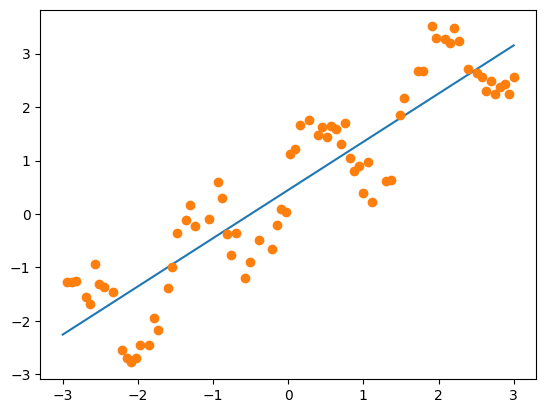

In [11]:
min_pt = X.min() * regressor.coef_[0] + regressor.intercept_
max_pt = X.max() * regressor.coef_[0] + regressor.intercept_

plt.plot([X.min(), X.max()], [min_pt, max_pt])
plt.plot(X_train, y_train, 'o');

Similar to the estimators for classification in the previous notebook, we use the `predict` method to predict the target variable. And we expect these predicted values to fall onto the line that we plotted previously:

In [13]:
y_pred_train = regressor.predict(X_train)

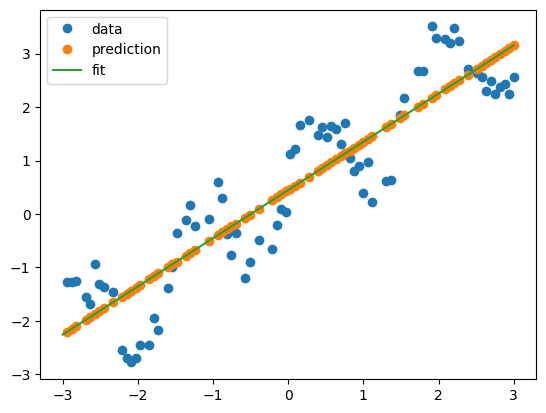

In [14]:
plt.plot(X_train, y_train, 'o', label="data")
plt.plot(X_train, y_pred_train, 'o', label="prediction")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label='fit')
plt.legend(loc='best')

As we can see in the plot above, the line is able to capture the general slope of the data, but not many details.

Next, let's try the test set:

In [15]:
y_pred_test = regressor.predict(X_test)

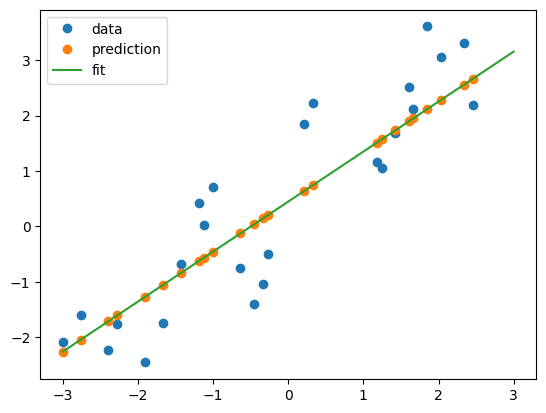

In [16]:
plt.plot(X_test, y_test, 'o', label="data")
plt.plot(X_test, y_pred_test, 'o', label="prediction")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label='fit')
plt.legend(loc='best');

Again, scikit-learn provides an easy way to evaluate the prediction quantitatively using the ``score`` method. For regression tasks, this is the R<sup>2</sup> score. Another popular way would be the Mean Squared Error (MSE). As its name implies, the MSE is simply the average squared difference over the predicted and actual target values

$$MSE = \frac{1}{n} \sum^{n}_{i=1} (\text{predicted}_i - \text{true}_i)^2$$

In [17]:
regressor.score(X_test, y_test)

0.7994321405079685

KNeighborsRegression
=======================
As for classification, we can also use a neighbor based method for regression. We can simply take the output of the nearest point, or we could average several nearest points. This method is less popular for regression than for classification, but still a good baseline.

In [18]:
from sklearn.neighbors import KNeighborsRegressor
kneighbor_regression = KNeighborsRegressor(n_neighbors=1)
kneighbor_regression.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=1)

Again, let us look at the behavior on training and test set:

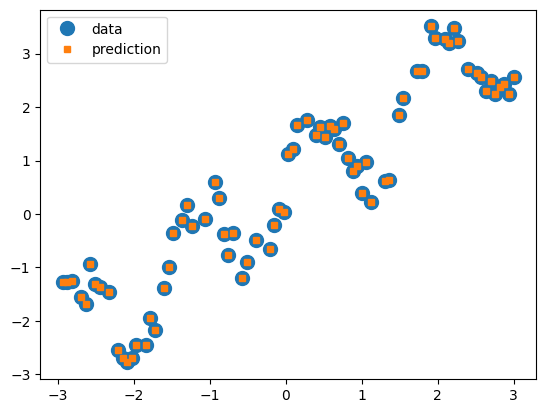

In [19]:
y_pred_train = kneighbor_regression.predict(X_train)

plt.plot(X_train, y_train, 'o', label="data", markersize=10)
plt.plot(X_train, y_pred_train, 's', label="prediction", markersize=4)
plt.legend(loc='best');

On the training set, we do a perfect job: each point is its own nearest neighbor!

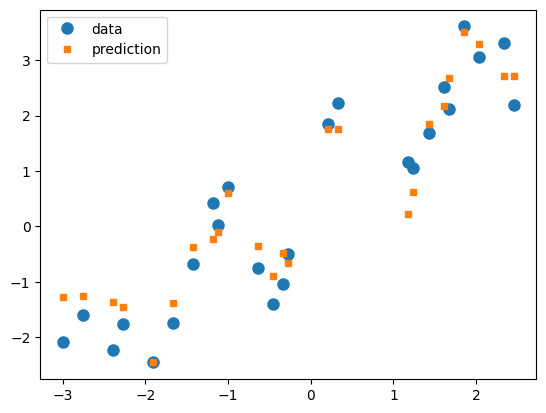

In [20]:
y_pred_test = kneighbor_regression.predict(X_test)

plt.plot(X_test, y_test, 'o', label="data", markersize=8)
plt.plot(X_test, y_pred_test, 's', label="prediction", markersize=4)
plt.legend(loc='best');

On the test set, we also do a better job of capturing the variation, but our estimates look much messier than before.
Let us look at the R<sup>2</sup> score:

In [21]:
kneighbor_regression.score(X_test, y_test)

0.9372504769740595

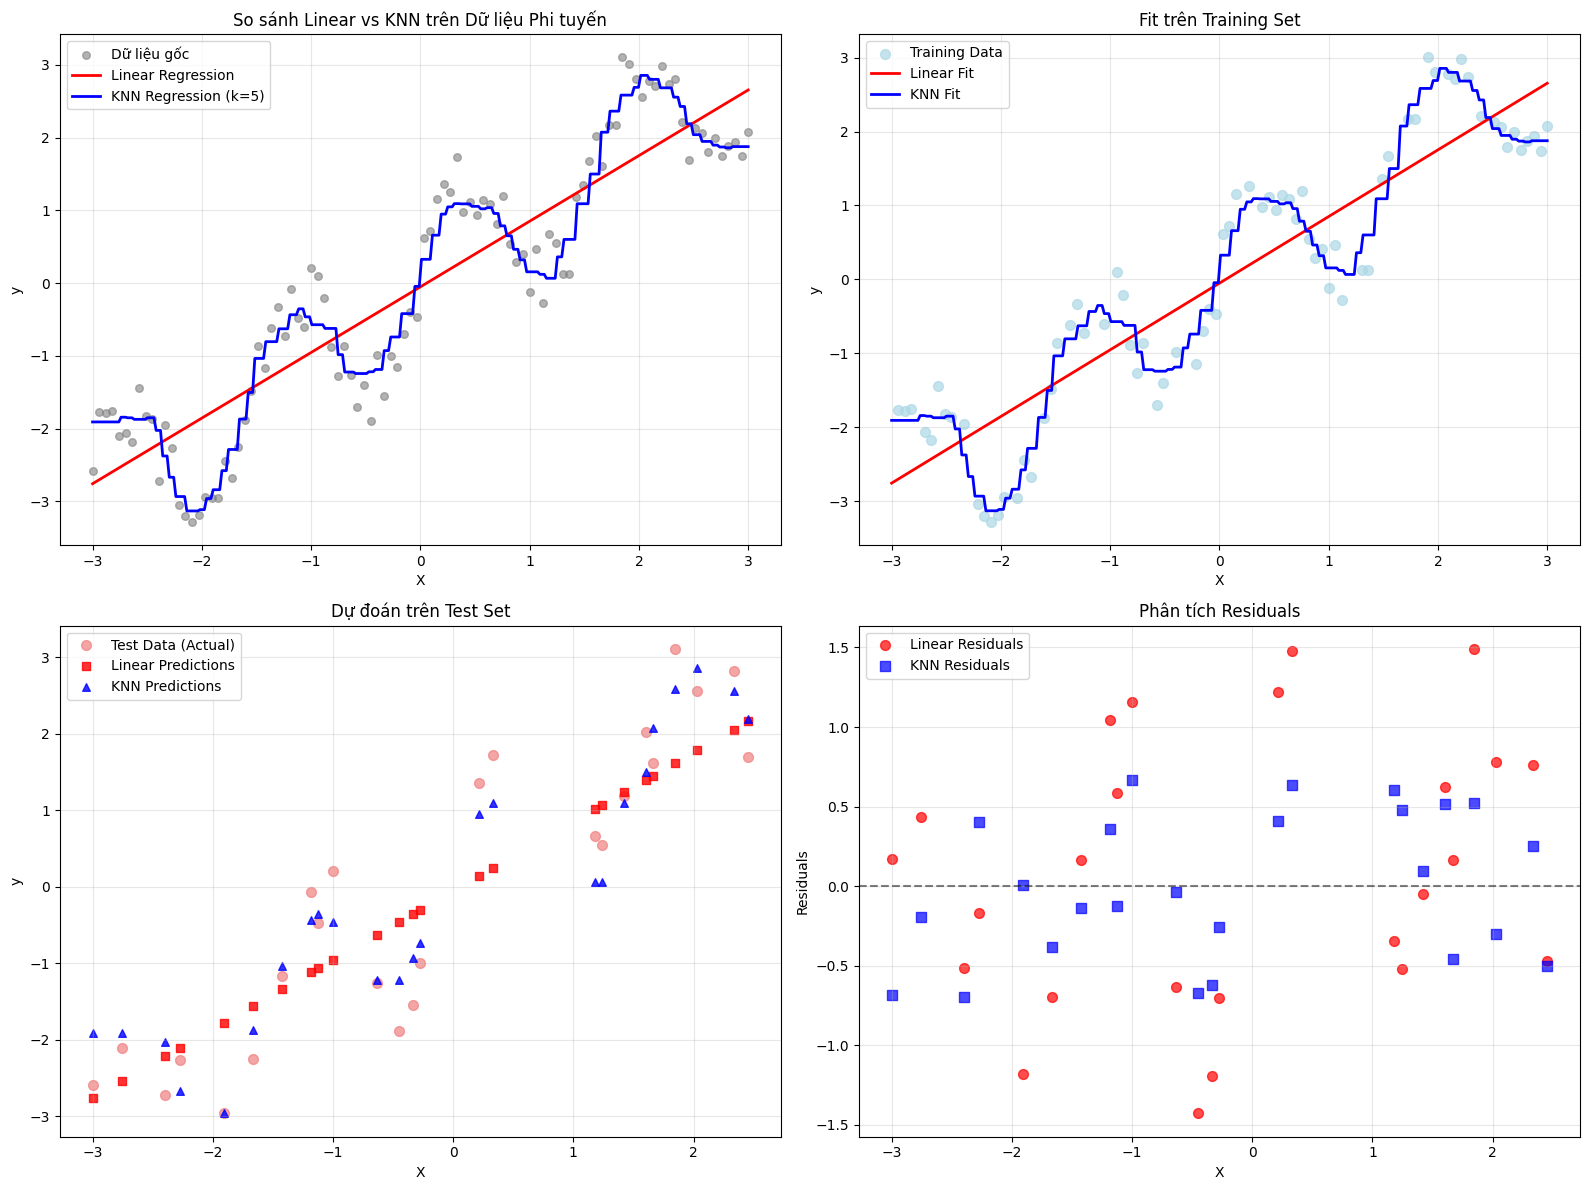

SO SÁNH PERFORMANCE GIỮA LINEAR vs KNN REGRESSION
Metric               Linear Reg   KNN Reg      Winner    
------------------------------------------------------------
R² Training          0.819        0.979        KNN       
R² Test              0.799        0.942        KNN       
MSE Test             0.706        0.205        KNN       
------------------------------------------------------------

PHÂN TÍCH KẾT QUẢ:
🏆 KNN REGRESSION THẮNG!
✅ KNN có thể nắm bắt được mối quan hệ phi tuyến tốt hơn
✅ Đường KNN fit sát với dữ liệu hơn Linear
⚠️  Tuy nhiên KNN có thể overfitting trên training set

📊 Chênh lệch R² Test: 0.142
📊 Chênh lệch MSE Test: 0.500

THAY ĐỔI K TRONG KNN REGRESSION:


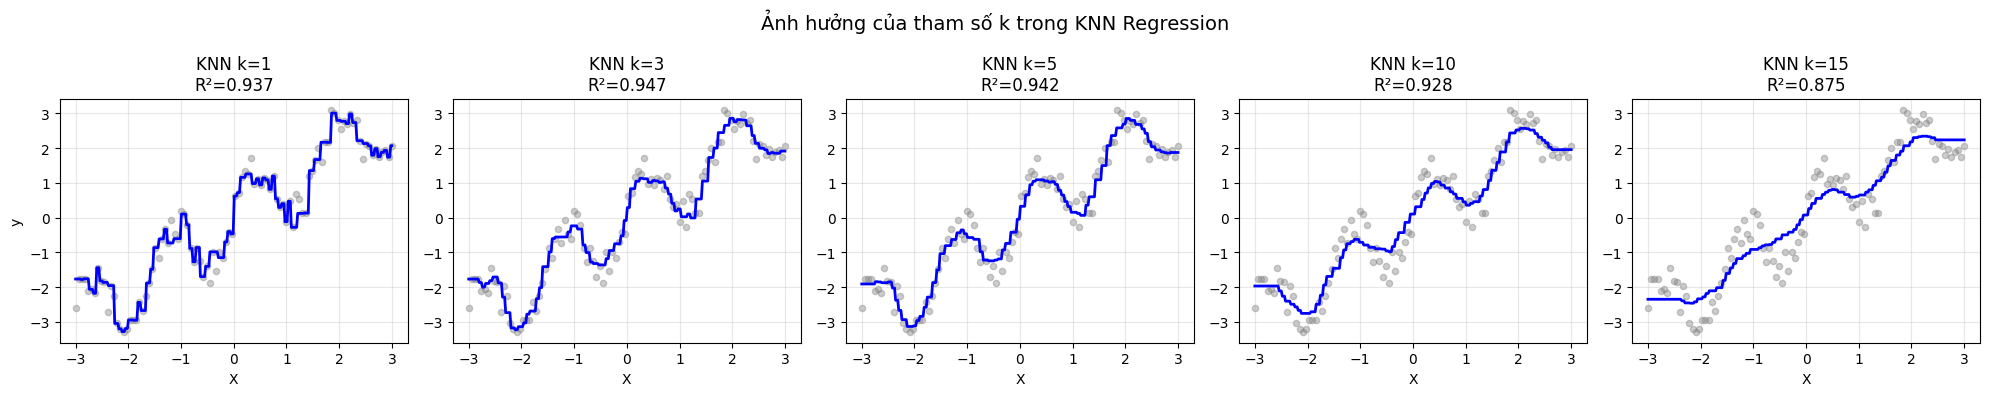


KẾT LUẬN CHÍNH:
🔸 Với dữ liệu PHI TUYẾN (sine wave):
   - Linear Regression: Chỉ nắm bắt được trend tuyến tính chung
   - KNN Regression: Có thể fit các pattern phức tạp hơn

🔸 Trade-offs:
   - Linear: Đơn giản, nhanh, dễ giải thích nhưng kém linh hoạt
   - KNN: Linh hoạt, fit tốt dữ liệu phức tạp nhưng dễ overfitting

🎯 Lựa chọn:
   - Dữ liệu tuyến tính → Linear Regression
   - Dữ liệu phi tuyến → KNN hoặc Polynomial Regression


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# 1. Tạo dữ liệu phi tuyến (sine wave + linear trend + noise)
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(4 * x) + x + np.random.uniform(-0.5, 0.5, size=len(x))

# Chuyển đổi thành 2D để phù hợp với scikit-learn
X = x.reshape(-1, 1)

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Huấn luyện cả hai mô hình
# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# KNN Regression (k=5 để smooth hơn k=1)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

# 3. Tạo dữ liệu để vẽ đường smooth
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_linear_pred = linear_reg.predict(X_plot)
y_knn_pred = knn_reg.predict(X_plot)

# Dự đoán trên test set
y_linear_test = linear_reg.predict(X_test)
y_knn_test = knn_reg.predict(X_test)

# 4. Tạo biểu đồ so sánh chi tiết
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Tổng quan so sánh trên toàn bộ dữ liệu
axes[0,0].scatter(x, y, alpha=0.6, c='gray', s=30, label='Dữ liệu gốc')
axes[0,0].plot(X_plot, y_linear_pred, 'r-', linewidth=2, label='Linear Regression')
axes[0,0].plot(X_plot, y_knn_pred, 'b-', linewidth=2, label='KNN Regression (k=5)')
axes[0,0].set_xlabel('X')
axes[0,0].set_ylabel('y')
axes[0,0].set_title('So sánh Linear vs KNN trên Dữ liệu Phi tuyến')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Performance trên Training Set
axes[0,1].scatter(X_train, y_train, alpha=0.7, c='lightblue', s=50, label='Training Data')
axes[0,1].plot(X_plot, y_linear_pred, 'r-', linewidth=2, label='Linear Fit')
axes[0,1].plot(X_plot, y_knn_pred, 'b-', linewidth=2, label='KNN Fit')
axes[0,1].set_xlabel('X')
axes[0,1].set_ylabel('y')
axes[0,1].set_title('Fit trên Training Set')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Performance trên Test Set
axes[1,0].scatter(X_test, y_test, alpha=0.7, c='lightcoral', s=50, label='Test Data (Actual)')
axes[1,0].scatter(X_test, y_linear_test, marker='s', alpha=0.8, c='red', s=30, label='Linear Predictions')
axes[1,0].scatter(X_test, y_knn_test, marker='^', alpha=0.8, c='blue', s=30, label='KNN Predictions')
axes[1,0].set_xlabel('X')
axes[1,0].set_ylabel('y')
axes[1,0].set_title('Dự đoán trên Test Set')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Residual Analysis
linear_residuals = y_test - y_linear_test
knn_residuals = y_test - y_knn_test

axes[1,1].scatter(X_test, linear_residuals, c='red', alpha=0.7, label='Linear Residuals', s=50)
axes[1,1].scatter(X_test, knn_residuals, c='blue', alpha=0.7, label='KNN Residuals', s=50, marker='s')
axes[1,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,1].set_xlabel('X')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Phân tích Residuals')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. So sánh metrics
linear_r2_train = linear_reg.score(X_train, y_train)
linear_r2_test = linear_reg.score(X_test, y_test)
knn_r2_train = knn_reg.score(X_train, y_train)
knn_r2_test = knn_reg.score(X_test, y_test)

print("=" * 60)
print("SO SÁNH PERFORMANCE GIỮA LINEAR vs KNN REGRESSION")
print("=" * 60)
print(f"{'Metric':<20} {'Linear Reg':<12} {'KNN Reg':<12} {'Winner':<10}")
print("-" * 60)
print(f"{'R² Training':<20} {linear_r2_train:<12.3f} {knn_r2_train:<12.3f} {'KNN' if knn_r2_train > linear_r2_train else 'Linear':<10}")
print(f"{'R² Test':<20} {linear_r2_test:<12.3f} {knn_r2_test:<12.3f} {'KNN' if knn_r2_test > linear_r2_test else 'Linear':<10}")

# 6. MSE Analysis
from sklearn.metrics import mean_squared_error
linear_mse = mean_squared_error(y_test, y_linear_test)
knn_mse = mean_squared_error(y_test, y_knn_test)
print(f"{'MSE Test':<20} {linear_mse:<12.3f} {knn_mse:<12.3f} {'KNN' if knn_mse < linear_mse else 'Linear':<10}")
print("-" * 60)

# 7. Interpretations
print("\n" + "=" * 60)
print("PHÂN TÍCH KẾT QUẢ:")
print("=" * 60)

if knn_r2_test > linear_r2_test:
    print("🏆 KNN REGRESSION THẮNG!")
    print("✅ KNN có thể nắm bắt được mối quan hệ phi tuyến tốt hơn")
    print("✅ Đường KNN fit sát với dữ liệu hơn Linear")
    print("⚠️  Tuy nhiên KNN có thể overfitting trên training set")
else:
    print("🏆 LINEAR REGRESSION THẮNG!")
    print("✅ Linear đơn giản và tổng quát hóa tốt")
    print("⚠️  Nhưng không phù hợp với dữ liệu phi tuyến")

print(f"\n📊 Chênh lệch R² Test: {abs(knn_r2_test - linear_r2_test):.3f}")
print(f"📊 Chênh lệch MSE Test: {abs(knn_mse - linear_mse):.3f}")

# 8. Demo với các k khác nhau cho KNN
print("\n" + "=" * 60)
print("THAY ĐỔI K TRONG KNN REGRESSION:")
print("=" * 60)

k_values = [1, 3, 5, 10, 15]
fig, axes = plt.subplots(1, len(k_values), figsize=(20, 4))

for i, k in enumerate(k_values):
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_plot)
    r2_score = knn_temp.score(X_test, y_test)
    
    axes[i].scatter(x, y, alpha=0.4, c='gray', s=20)
    axes[i].plot(X_plot, y_pred_temp, 'b-', linewidth=2)
    axes[i].set_title(f'KNN k={k}\nR²={r2_score:.3f}')
    axes[i].set_xlabel('X')
    if i == 0:
        axes[i].set_ylabel('y')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Ảnh hưởng của tham số k trong KNN Regression', fontsize=14)
plt.tight_layout()
plt.show()

# 9. Kết luận cuối cùng
print("\n" + "=" * 60)
print("KẾT LUẬN CHÍNH:")
print("=" * 60)
print("🔸 Với dữ liệu PHI TUYẾN (sine wave):")
print("   - Linear Regression: Chỉ nắm bắt được trend tuyến tính chung")
print("   - KNN Regression: Có thể fit các pattern phức tạp hơn")
print("\n🔸 Trade-offs:")
print("   - Linear: Đơn giản, nhanh, dễ giải thích nhưng kém linh hoạt")
print("   - KNN: Linh hoạt, fit tốt dữ liệu phức tạp nhưng dễ overfitting")
print("\n🎯 Lựa chọn:")
print("   - Dữ liệu tuyến tính → Linear Regression")
print("   - Dữ liệu phi tuyến → KNN hoặc Polynomial Regression")

Much better than before! Here, the linear model was not a good fit for our problem; it was lacking in complexity and thus under-fit our data.

Exercise
=========
Compare the KNeighborsRegressor and LinearRegression on the boston housing dataset. You can load the dataset using ``sklearn.datasets.load_boston``. You can learn about the dataset by reading the ``DESCR`` attribute.

In [44]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X, y = california.data, california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Tuyến tính
linear_reg = LinearRegression()
knn_reg = KNeighborsRegressor(n_neighbors=5)

linear_reg.fit(X_train, y_train)
knn_reg.fit(X_train, y_train)

linear_r2 = linear_reg.score(X_test, y_test)
knn_r2 = knn_reg.score(X_test, y_test)

print(f"California Housing - R² Linear: {linear_r2:.3f}, R² KNN: {knn_r2:.3f}")

California Housing - R² Linear: 0.591, R² KNN: 0.144


In [45]:
# Thử với Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_train, y_train)

tree_r2 = tree_reg.score(X_test, y_test)

print(f"California Housing - R² Decision Tree: {tree_r2:.3f}")


California Housing - R² Decision Tree: 0.602


In [20]:
# %load solutions/06A_knn_vs_linreg.py